# Importing Libraries 

In [2]:

import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import math
import statistics
import pylab

# Data Loading and Cleaning

In [3]:
df = pd.read_csv(r'E:\Data Analyst Roadmap\Google Data Analytics Certificate Course\Different Analysis\Vehicle Dataset\Cleaning and Analysis in Python\Car details v3.csv')

In [4]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [5]:
for i in df.select_dtypes('object').columns:
    print(df[i].unique())

['Maruti Swift Dzire VDI' 'Skoda Rapid 1.5 TDI Ambition'
 'Honda City 2017-2020 EXi' ... 'Tata Nexon 1.5 Revotorq XT'
 'Ford Freestyle Titanium Plus Diesel BSIV'
 'Toyota Innova 2.5 GX (Diesel) 8 Seater BS IV']
['Diesel' 'Petrol' 'LPG' 'CNG']
['Individual' 'Dealer' 'Trustmark Dealer']
['Manual' 'Automatic']
['First Owner' 'Second Owner' 'Third Owner' 'Fourth & Above Owner'
 'Test Drive Car']
['23.4 kmpl' '21.14 kmpl' '17.7 kmpl' '23.0 kmpl' '16.1 kmpl' '20.14 kmpl'
 '17.3 km/kg' '23.59 kmpl' '20.0 kmpl' '19.01 kmpl' '17.3 kmpl'
 '19.3 kmpl' nan '18.9 kmpl' '18.15 kmpl' '24.52 kmpl' '19.7 kmpl'
 '22.54 kmpl' '21.0 kmpl' '25.5 kmpl' '26.59 kmpl' '21.5 kmpl' '20.3 kmpl'
 '21.4 kmpl' '24.7 kmpl' '18.2 kmpl' '16.8 kmpl' '24.3 kmpl' '14.0 kmpl'
 '18.6 kmpl' '33.44 km/kg' '23.95 kmpl' '17.0 kmpl' '20.63 kmpl'
 '13.93 kmpl' '16.0 kmpl' '17.8 kmpl' '18.5 kmpl' '12.55 kmpl'
 '12.99 kmpl' '14.8 kmpl' '13.5 kmpl' '26.0 kmpl' '20.65 kmpl' '27.3 kmpl'
 '11.36 kmpl' '17.68 kmpl' '14.28 kmpl' '18.53 k

In [6]:
df.drop(columns=['torque'],inplace=True)

In [7]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,5.0


In [8]:
df.shape

(8128, 12)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(8)
memory usage: 762.1+ KB


In [10]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
seats            221
dtype: int64

In [11]:
(df.isnull().sum()/8128)*100

name             0.000000
year             0.000000
selling_price    0.000000
km_driven        0.000000
fuel             0.000000
seller_type      0.000000
transmission     0.000000
owner            0.000000
mileage          2.718996
engine           2.718996
max_power        2.645177
seats            2.718996
dtype: float64

In [12]:
df.dropna(inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7907 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           7907 non-null   object 
 1   year           7907 non-null   int64  
 2   selling_price  7907 non-null   int64  
 3   km_driven      7907 non-null   int64  
 4   fuel           7907 non-null   object 
 5   seller_type    7907 non-null   object 
 6   transmission   7907 non-null   object 
 7   owner          7907 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7907 non-null   object 
 11  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(8)
memory usage: 803.1+ KB


In [14]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,5.0


In [15]:
df.rename(columns={'mileage':'mileage (kmpl)','engine':'engine (cc)'},inplace=True)

In [16]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage (kmpl),engine (cc),max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,5.0


In [17]:
df['mileage (kmpl)'].unique()

array(['23.4 kmpl', '21.14 kmpl', '17.7 kmpl', '23.0 kmpl', '16.1 kmpl',
       '20.14 kmpl', '17.3 km/kg', '23.59 kmpl', '20.0 kmpl',
       '19.01 kmpl', '17.3 kmpl', '19.3 kmpl', '18.9 kmpl', '18.15 kmpl',
       '24.52 kmpl', '19.7 kmpl', '22.54 kmpl', '21.0 kmpl', '25.5 kmpl',
       '26.59 kmpl', '21.5 kmpl', '20.3 kmpl', '21.4 kmpl', '24.7 kmpl',
       '18.2 kmpl', '16.8 kmpl', '24.3 kmpl', '14.0 kmpl', '18.6 kmpl',
       '33.44 km/kg', '23.95 kmpl', '17.0 kmpl', '20.63 kmpl',
       '13.93 kmpl', '16.0 kmpl', '17.8 kmpl', '18.5 kmpl', '12.55 kmpl',
       '12.99 kmpl', '14.8 kmpl', '13.5 kmpl', '26.0 kmpl', '20.65 kmpl',
       '27.3 kmpl', '11.36 kmpl', '17.68 kmpl', '14.28 kmpl',
       '18.53 kmpl', '14.84 kmpl', '21.12 kmpl', '20.36 kmpl',
       '21.27 kmpl', '18.16 kmpl', '22.0 kmpl', '25.1 kmpl', '20.51 kmpl',
       '21.66 kmpl', '25.2 kmpl', '22.9 kmpl', '16.02 kmpl', '20.54 kmpl',
       '22.77 kmpl', '15.71 kmpl', '23.1 kmpl', '19.02 kmpl',
       '19.81 kmpl', '26

In [18]:
df['mileage (kmpl)'].str.split(" ")

0        [23.4, kmpl]
1       [21.14, kmpl]
2        [17.7, kmpl]
3        [23.0, kmpl]
4        [16.1, kmpl]
            ...      
8123     [18.5, kmpl]
8124     [16.8, kmpl]
8125     [19.3, kmpl]
8126    [23.57, kmpl]
8127    [23.57, kmpl]
Name: mileage (kmpl), Length: 7907, dtype: object

In [19]:
a = '134 kmpl'

In [20]:
x = a.split(' ')

In [21]:
x

['134', 'kmpl']

In [22]:
int(x[0] *2)

134134

In [23]:
def Milage_Converter(data):
    x = data.split(' ')
    if(x[1]=='kmpl'):
        return str(float(x[0])*1)
    elif(x[1]=='km/kg'):
        return str(round(float(x[0]) * 1.4, 2))

In [24]:
df['mileage (kmpl)']=df['mileage (kmpl)'].apply(Milage_Converter)

In [25]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage (kmpl),engine (cc),max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4,1248 CC,74 bhp,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498 CC,103.52 bhp,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7,1497 CC,78 bhp,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0,1396 CC,90 bhp,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1,1298 CC,88.2 bhp,5.0


In [26]:
df['mileage (kmpl)'] = pd.to_numeric(df['mileage (kmpl)'])

In [27]:
df['engine (cc)']=df['engine (cc)'].str.strip('CC')

In [28]:
df['engine (cc)'] = pd.to_numeric(df['engine (cc)'])

In [29]:
def categorize_engine(cc):
    if cc <= 1000:
        return 'Less Than 1000 CC'
    elif 1001 <= cc <= 1500:
        return '1001 CC - 1500 CC'
    else:
        return 'More Than 1500 CC'

In [30]:
df['engine (cc)'] = df['engine (cc)'].apply(categorize_engine)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7907 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            7907 non-null   object 
 1   year            7907 non-null   int64  
 2   selling_price   7907 non-null   int64  
 3   km_driven       7907 non-null   int64  
 4   fuel            7907 non-null   object 
 5   seller_type     7907 non-null   object 
 6   transmission    7907 non-null   object 
 7   owner           7907 non-null   object 
 8   mileage (kmpl)  7907 non-null   float64
 9   engine (cc)     7907 non-null   object 
 10  max_power       7907 non-null   object 
 11  seats           7907 non-null   float64
dtypes: float64(2), int64(3), object(7)
memory usage: 803.1+ KB


In [32]:
df.rename(columns={'max_power':'max_power (bhp)'},inplace=True)

In [33]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage (kmpl),engine (cc),max_power (bhp),seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1001 CC - 1500 CC,74 bhp,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1001 CC - 1500 CC,103.52 bhp,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1001 CC - 1500 CC,78 bhp,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1001 CC - 1500 CC,90 bhp,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1001 CC - 1500 CC,88.2 bhp,5.0


In [34]:
df['max_power (bhp)']=df['max_power (bhp)'].str.strip('bhp')

In [35]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage (kmpl),engine (cc),max_power (bhp),seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1001 CC - 1500 CC,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1001 CC - 1500 CC,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1001 CC - 1500 CC,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1001 CC - 1500 CC,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1001 CC - 1500 CC,88.2,5.0


In [36]:
df['max_power (bhp)'] = pd.to_numeric(df['max_power (bhp)'],errors='coerce')

In [37]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage (kmpl),engine (cc),max_power (bhp),seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1001 CC - 1500 CC,74.00,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1001 CC - 1500 CC,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1001 CC - 1500 CC,78.00,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1001 CC - 1500 CC,90.00,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1001 CC - 1500 CC,88.20,5.0


In [38]:
df['seats']=df['seats'].astype('int')

In [39]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage (kmpl),engine (cc),max_power (bhp),seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1001 CC - 1500 CC,74.00,5
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1001 CC - 1500 CC,103.52,5
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1001 CC - 1500 CC,78.00,5
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1001 CC - 1500 CC,90.00,5
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1001 CC - 1500 CC,88.20,5


In [40]:
df.dropna(inplace=True)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7906 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             7906 non-null   object 
 1   year             7906 non-null   int64  
 2   selling_price    7906 non-null   int64  
 3   km_driven        7906 non-null   int64  
 4   fuel             7906 non-null   object 
 5   seller_type      7906 non-null   object 
 6   transmission     7906 non-null   object 
 7   owner            7906 non-null   object 
 8   mileage (kmpl)   7906 non-null   float64
 9   engine (cc)      7906 non-null   object 
 10  max_power (bhp)  7906 non-null   float64
 11  seats            7906 non-null   int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 803.0+ KB


# EDA and Statistical Analysis

In [42]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage (kmpl),engine (cc),max_power (bhp),seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1001 CC - 1500 CC,74.00,5
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1001 CC - 1500 CC,103.52,5
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1001 CC - 1500 CC,78.00,5
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1001 CC - 1500 CC,90.00,5
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1001 CC - 1500 CC,88.20,5


In [43]:
df.describe()

,year,selling_price,km_driven,mileage (kmpl),max_power (bhp),seats
count,7906.000000,7.906000e+03,7.906000e+03,7906.000000,7906.000000,7906.000000
mean,2013.983936,6.498137e+05,6.918866e+04,19.517014,91.587374,5.416393
std,3.863695,8.135827e+05,5.679230e+04,4.244420,35.747216,0.959208
min,1994.000000,2.999900e+04,1.000000e+00,0.000000,32.800000,2.000000
25%,2012.000000,2.700000e+05,3.500000e+04,16.780000,68.050000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.330000,82.000000,5.000000
75%,2017.000000,6.900000e+05,9.542500e+04,22.320000,102.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,46.820000,400.000000,14.000000


In [44]:
plt.rcdefaults()

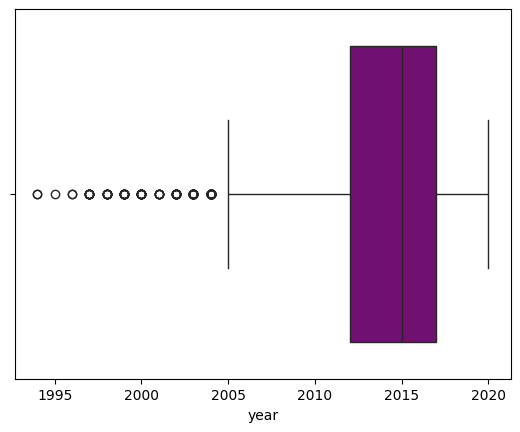

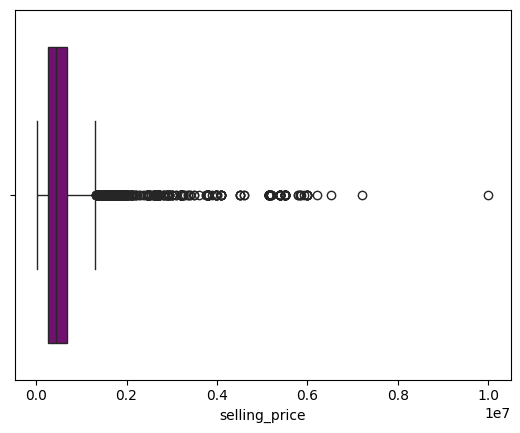

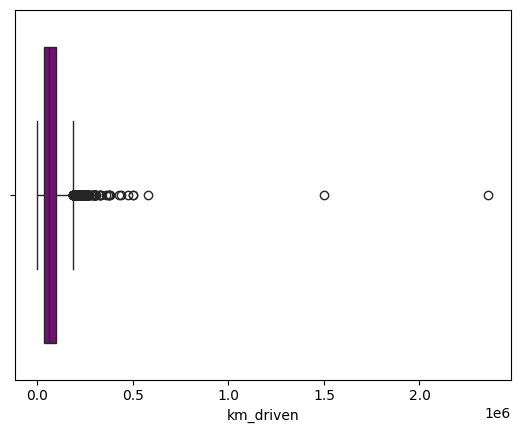

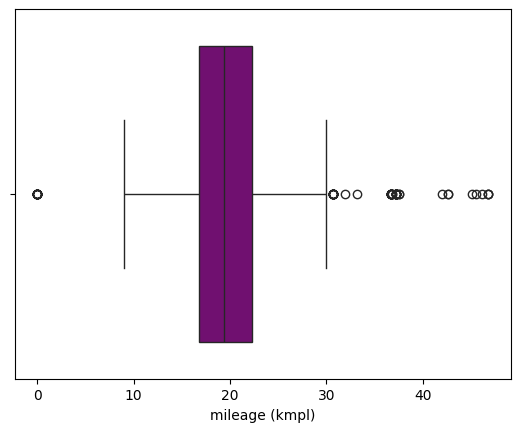

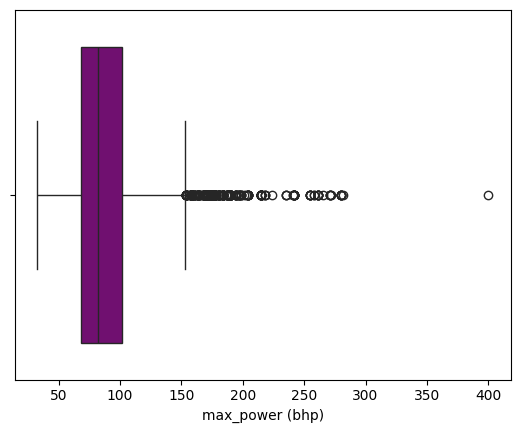

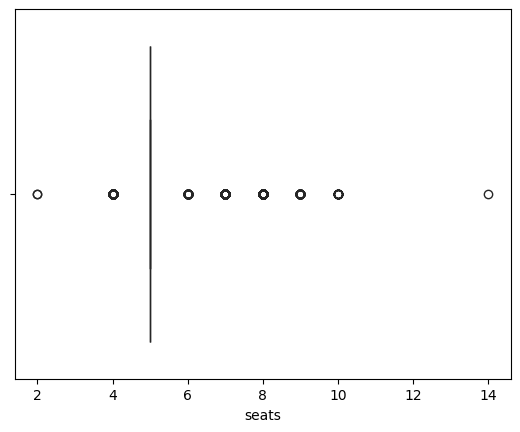

In [45]:
for i in df.select_dtypes('number').columns:
    sns.boxplot(data=df,x=i,color='Purple')
    plt.show()

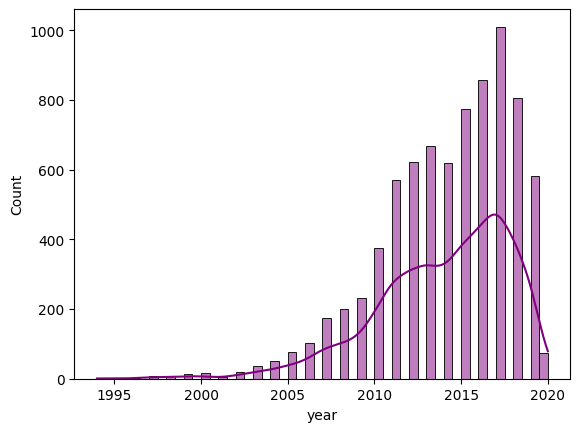

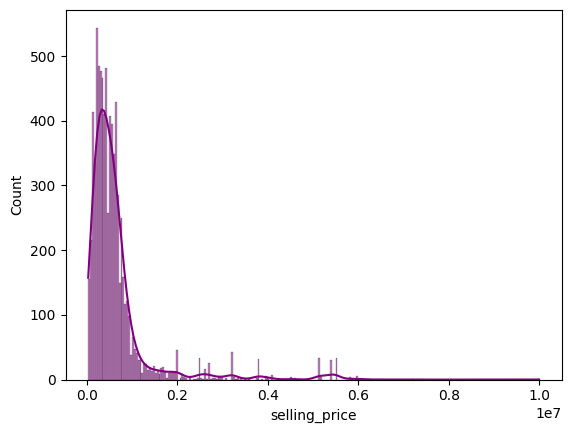

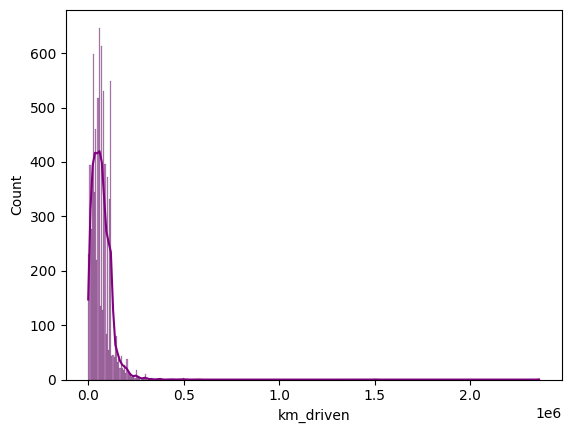

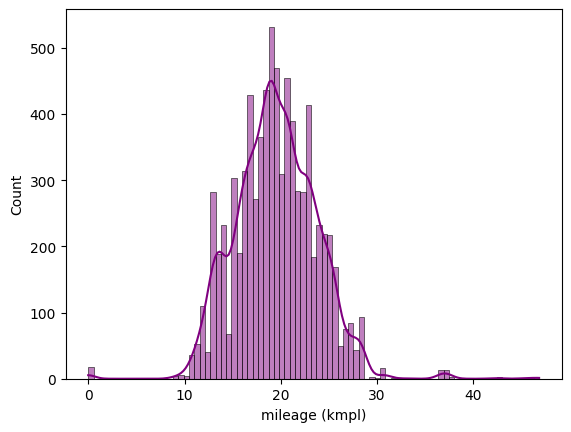

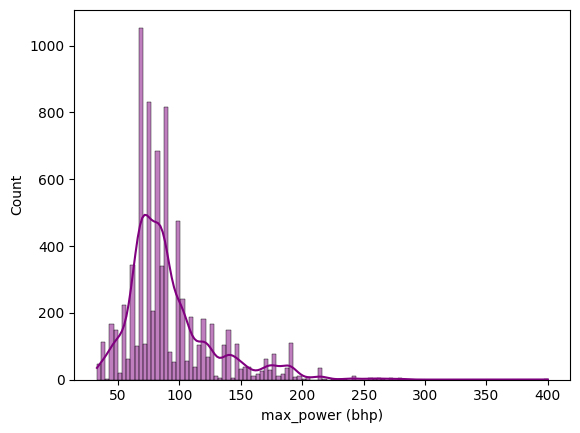

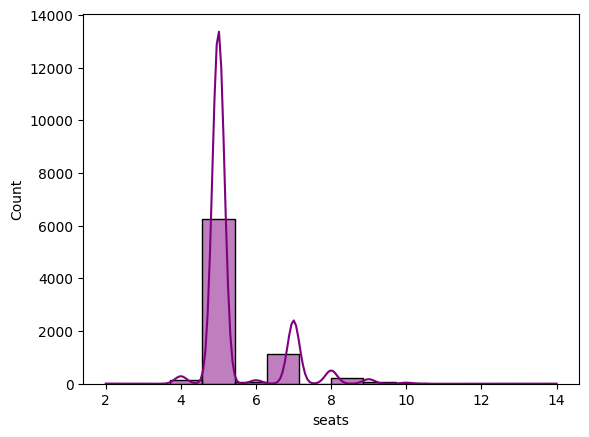

In [46]:
for i in df.select_dtypes('number').columns:
    sns.histplot(data=df,x=i,kde=True,color='Purple')
    plt.show()

In [47]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage (kmpl),engine (cc),max_power (bhp),seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1001 CC - 1500 CC,74.00,5
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1001 CC - 1500 CC,103.52,5
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1001 CC - 1500 CC,78.00,5
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1001 CC - 1500 CC,90.00,5
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1001 CC - 1500 CC,88.20,5


In [48]:
q1 = df['km_driven'].quantile(0.25)
q3 = df['km_driven'].quantile(0.75)
IQR = q3-q1
lower_bound = q1-1.5*IQR
upper_bound = q3+1.5*IQR

print(lower_bound)

print(upper_bound)

-55637.5
186062.5


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7906 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             7906 non-null   object 
 1   year             7906 non-null   int64  
 2   selling_price    7906 non-null   int64  
 3   km_driven        7906 non-null   int64  
 4   fuel             7906 non-null   object 
 5   seller_type      7906 non-null   object 
 6   transmission     7906 non-null   object 
 7   owner            7906 non-null   object 
 8   mileage (kmpl)   7906 non-null   float64
 9   engine (cc)      7906 non-null   object 
 10  max_power (bhp)  7906 non-null   float64
 11  seats            7906 non-null   int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 803.0+ KB


In [50]:
df = df[(df['km_driven']>lower_bound)&(df['km_driven']<upper_bound)]
df=df[(df['mileage (kmpl)']>0) & (df['mileage (kmpl)']<40)]
df=df[df['seats']<=10]
df=df[df['max_power (bhp)']<=200]
df=df[df['year']>=2005]

In [51]:
q1 = df['selling_price'].quantile(0.25)
q3 = df['selling_price'].quantile(0.75)
IQR = q3-q1
lower_bound = q1-1.5*IQR
upper_bound = q3+1.5*IQR
df=df[(df['selling_price']>lower_bound)&(df['selling_price']<upper_bound)]

In [52]:
df = df[df['owner']!='Fourth & Above Owner']

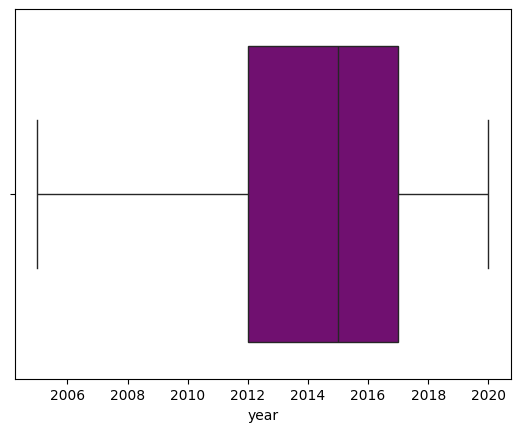

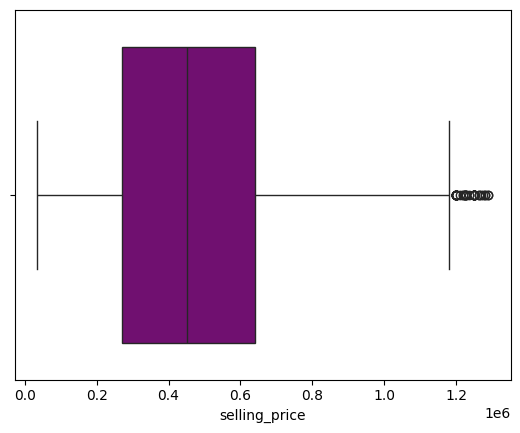

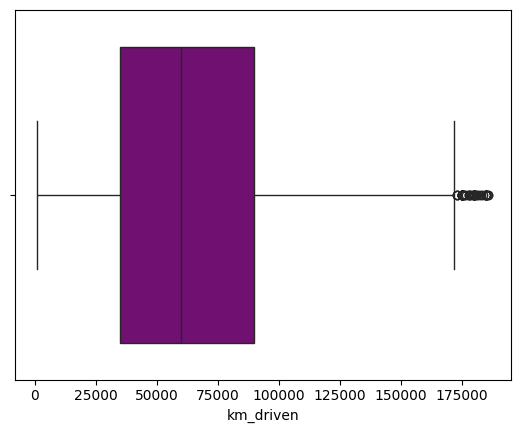

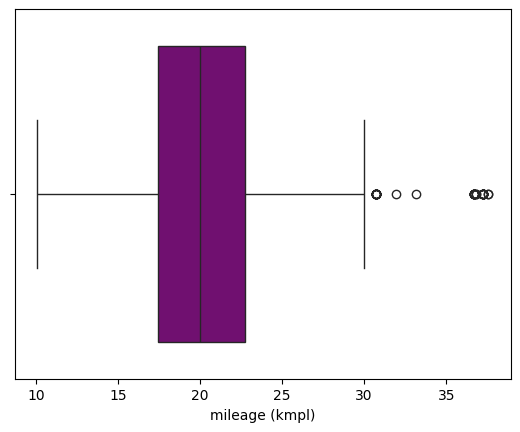

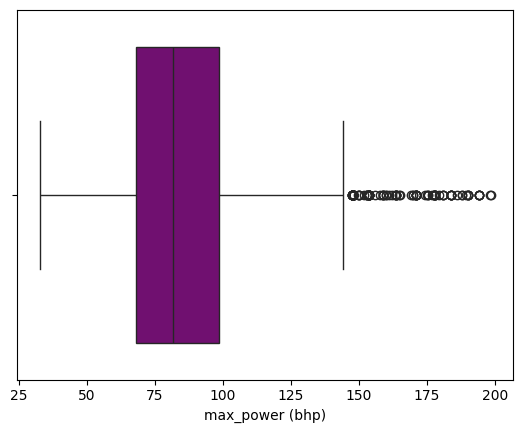

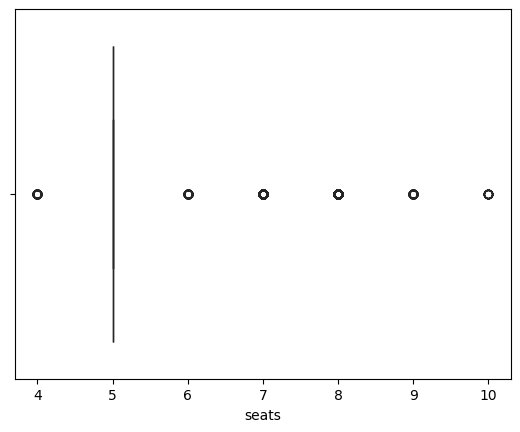

In [53]:
for i in df.select_dtypes('number').columns:
    sns.boxplot(data=df,x=i,color='Purple')
    plt.show()

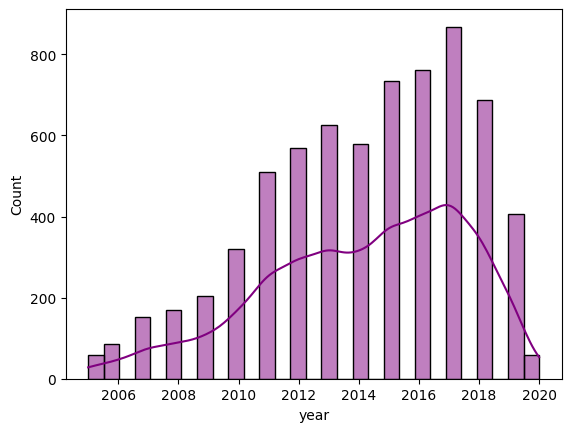

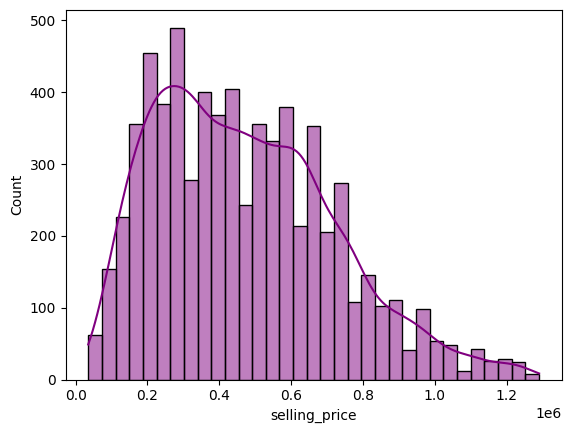

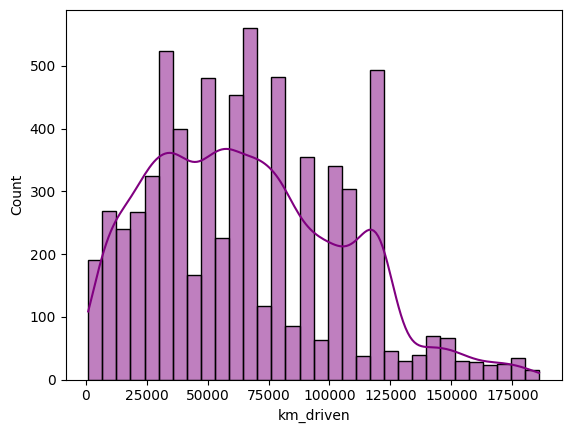

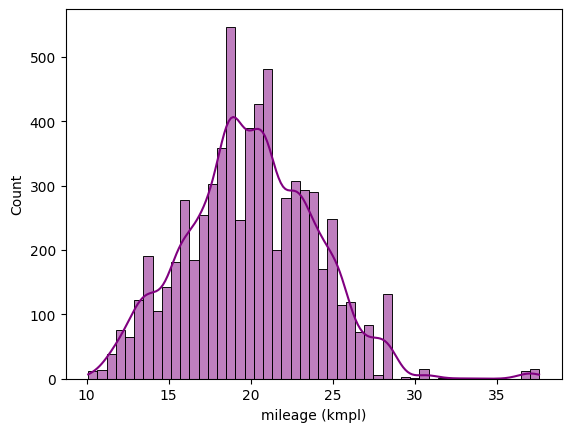

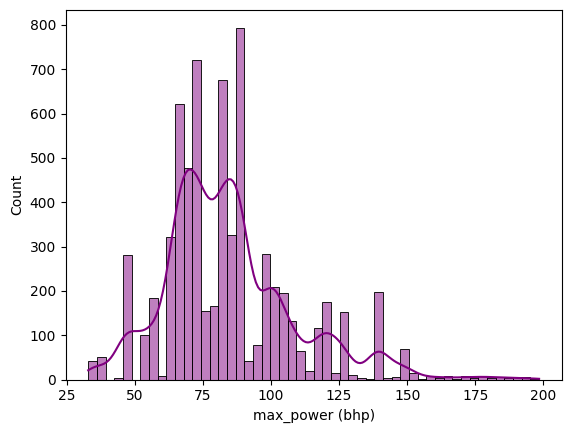

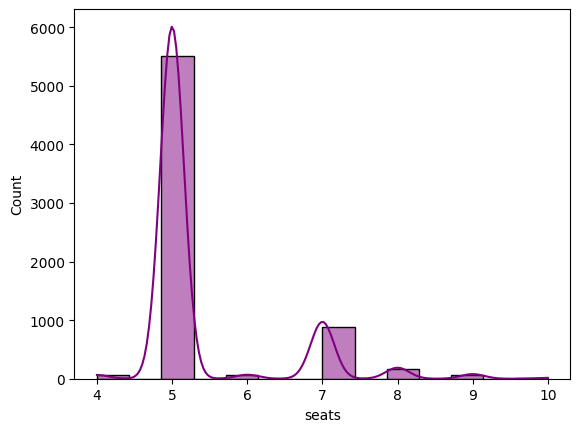

In [54]:
for i in df.select_dtypes('number').columns:
    sns.histplot(data=df,x=i,kde=True,color='Purple')
    plt.show()

#  Analysis


In [55]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage (kmpl),engine (cc),max_power (bhp),seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1001 CC - 1500 CC,74.00,5
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1001 CC - 1500 CC,103.52,5
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1001 CC - 1500 CC,78.00,5
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1001 CC - 1500 CC,90.00,5
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1001 CC - 1500 CC,88.20,5


In [56]:
Selling_Price = df['selling_price'].value_counts()
Transmission = df['transmission']

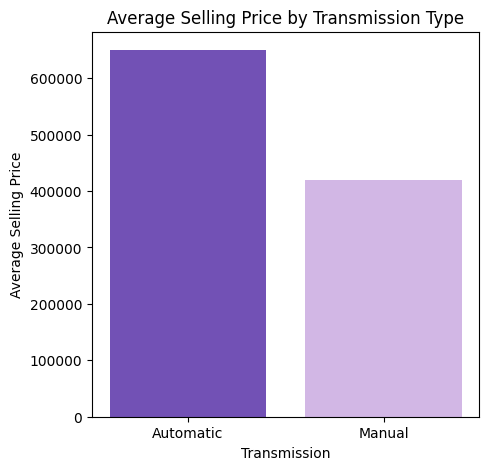

In [57]:
mean_selling_price = df.groupby('transmission')['selling_price'].median()

# Plot the bar plot
plt.figure(figsize=(5,5))
plt.bar(mean_selling_price.index, mean_selling_price.values, color=['#7251b5', '#d2b7e5'])
plt.xlabel('Transmission')
plt.ylabel('Average Selling Price')
plt.title('Average Selling Price by Transmission Type')
plt.show()

In [58]:
print(mean_selling_price)

transmission
Automatic    650000.0
Manual       420000.0
Name: selling_price, dtype: float64


In [1121]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage (kmpl),engine (cc),max_power (bhp),seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1001 CC - 1500 CC,74.00,5
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1001 CC - 1500 CC,103.52,5
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1001 CC - 1500 CC,78.00,5
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1001 CC - 1500 CC,90.00,5
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1001 CC - 1500 CC,88.20,5


In [1122]:
correlation = df.corr(numeric_only=True)

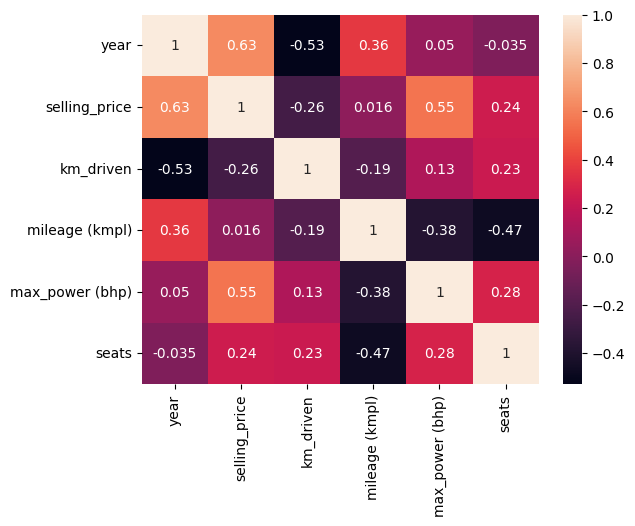

In [1123]:
sns.heatmap(correlation,annot=True)
plt.show()

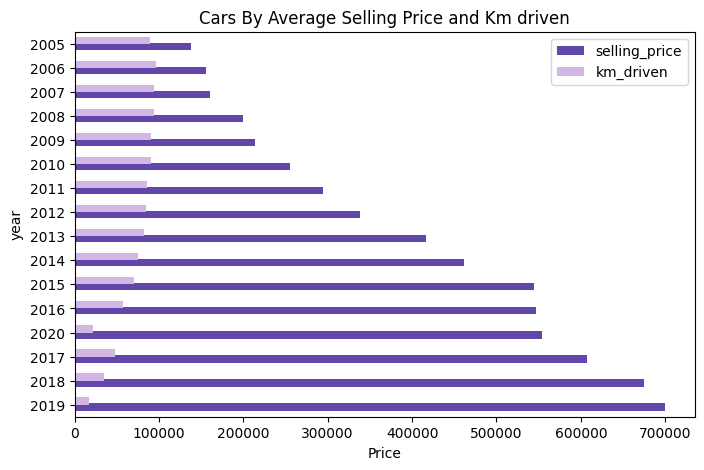

In [1124]:
ax = df.groupby('year').agg({'selling_price': 'mean', 'km_driven': 'mean'}).sort_values(by='selling_price', ascending=False).plot(
    kind='barh',
    figsize=(8, 5),  # Adjust the figure size (width, height)
    title='Cars By Average Selling Price and Km driven',
    xlabel='Price',
    color=['#6247aa', '#d2b7e5'],
        # Specify desired colors
)

# Adjust bar width
for bar in ax.patches:
    bar.set_height(0.3)
# Show the plot
plt.show()

In [1125]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage (kmpl),engine (cc),max_power (bhp),seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1001 CC - 1500 CC,74.00,5
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1001 CC - 1500 CC,103.52,5
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1001 CC - 1500 CC,78.00,5
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1001 CC - 1500 CC,90.00,5
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1001 CC - 1500 CC,88.20,5


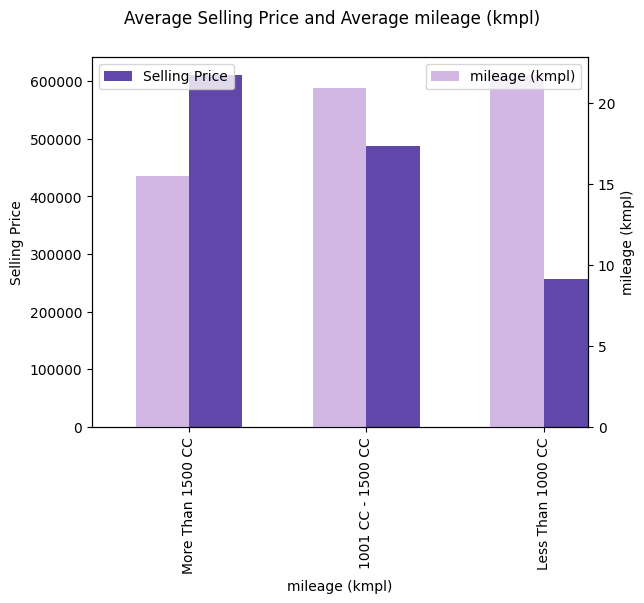

In [1126]:
# Group and aggregate the DataFrame
grouped_df = df.groupby('engine (cc)').agg({'selling_price': 'mean', 'mileage (kmpl)': 'mean'}).sort_values(by='selling_price', ascending=False)
# Plot
fig, ax1 = plt.subplots()

# Plot selling price
grouped_df['selling_price'].plot(kind='bar', ax=ax1, color='#6247aa', width=0.3, position=0, label='Selling Price')
ax1.set_ylabel('Selling Price', color='black')
ax1.set_xlabel('mileage (kmpl)')
ax1.tick_params(axis='y', labelcolor='black')

# Create a secondary y-axis for Mileage
ax2 = ax1.twinx()
grouped_df['mileage (kmpl)'].plot(kind='bar', ax=ax2, color='#d2b7e5', width=0.3, position=1, label='mileage (kmpl)')
ax2.set_ylabel('mileage (kmpl)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Title and legend
fig.suptitle('Average Selling Price and Average mileage (kmpl)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()

In [1127]:
g = df.groupby(['fuel','transmission','seats']).agg({'selling_price':'mean'}).reset_index()

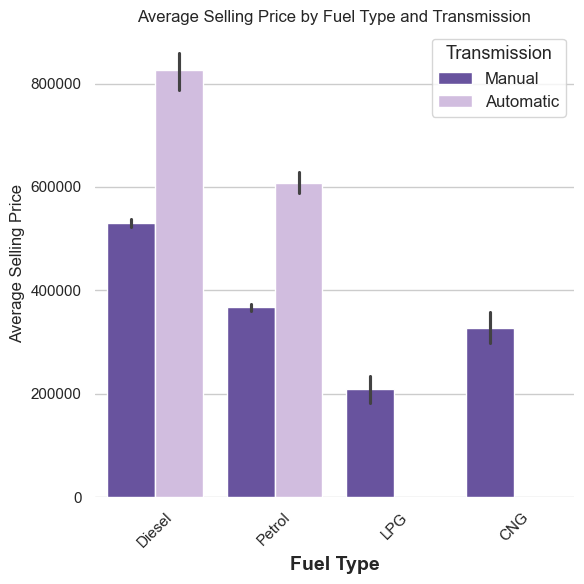

In [1128]:
plt.figure(figsize=(6, 6))
sns.set(style='whitegrid')
bar_plot = sns.barplot(x='fuel', y='selling_price', hue='transmission', data=df, palette=['#6247aa', '#d2b7e5'])

# Customize the plot
plt.title('Average Selling Price by Fuel Type and Transmission')
plt.xlabel('Fuel Type', fontsize=14, fontweight='bold')
plt.ylabel('Average Selling Price')
plt.legend(title='Transmission', title_fontsize='13', fontsize='12')
plt.xticks(rotation=45)

# Remove spines
sns.despine(left=True, bottom=True)

# Show the plot
plt.tight_layout()
plt.show()

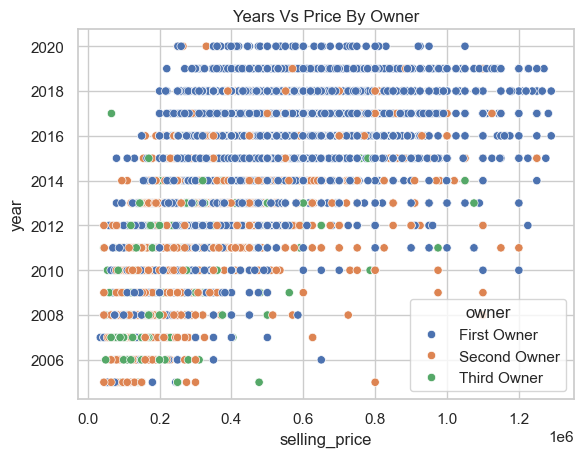

In [1129]:
plt.title('Years Vs Price By Owner')
sns.scatterplot(data=df,x='selling_price',y='year',hue='owner')
plt.show()

In [1130]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage (kmpl),engine (cc),max_power (bhp),seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1001 CC - 1500 CC,74.00,5
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1001 CC - 1500 CC,103.52,5
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1001 CC - 1500 CC,78.00,5
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1001 CC - 1500 CC,90.00,5
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1001 CC - 1500 CC,88.20,5


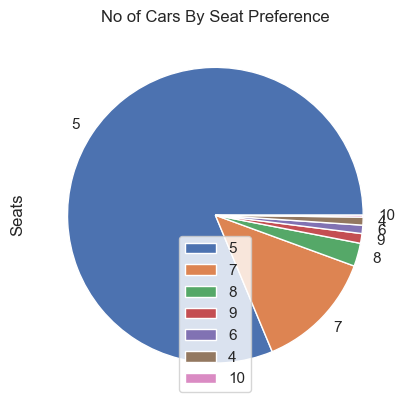

In [1131]:
Seats = df['seats'].value_counts().plot(kind='pie',title='No of Cars By Seat Preference',legend=True,ylabel='Seats')

In [1132]:
# Remove duplicates based on the 'Name' column
distinct_cars_df = df.drop_duplicates(subset='name')

# Sort the DataFrame by 'mileage (kmpl)' in descending order and get the top 10 rows
Top10_Cars = distinct_cars_df.sort_values(by='mileage (kmpl)', ascending=False).head(10)

# Display the top 10 cars
Top10_Cars


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage (kmpl),engine (cc),max_power (bhp),seats
7300,Maruti Alto Green LXi (CNG),2012,150000,82300,CNG,Individual,Manual,Second Owner,37.56,Less Than 1000 CC,38.40,5
203,Maruti Wagon R LXI CNG,2016,360000,50000,CNG,Individual,Manual,First Owner,37.24,Less Than 1000 CC,58.16,5
6488,Maruti Wagon R LXI CNG Optional,2019,459999,35000,CNG,Individual,Manual,First Owner,37.24,Less Than 1000 CC,58.16,5
2740,Maruti Zen Estilo LXI Green (CNG),2011,200000,80000,CNG,Individual,Manual,First Owner,36.82,Less Than 1000 CC,67.10,5
90,Maruti Wagon R LXI LPG BSIV,2010,225000,44000,LPG,Dealer,Manual,First Owner,36.68,Less Than 1000 CC,58.20,5
870,Maruti Wagon R Duo Lxi,2012,231000,70000,LPG,Individual,Manual,First Owner,36.68,Less Than 1000 CC,58.20,5
2758,Tata Indica V2 Emax CNG GLX,2015,155000,60000,CNG,Individual,Manual,Second Owner,33.18,1001 CC - 1500 CC,55.23,5
5749,Maruti Ertiga VXI CNG Limited Edition,2014,545000,35000,CNG,Individual,Manual,First Owner,31.92,1001 CC - 1500 CC,80.90,7
5198,Maruti Eeco CNG HTR 5-STR,2014,300000,90000,CNG,Individual,Manual,First Owner,30.72,1001 CC - 1500 CC,63.00,5
1225,Maruti Eeco CNG 5 Seater AC BSIV,2019,450000,10000,CNG,Individual,Manual,First Owner,30.72,1001 CC - 1500 CC,61.70,5


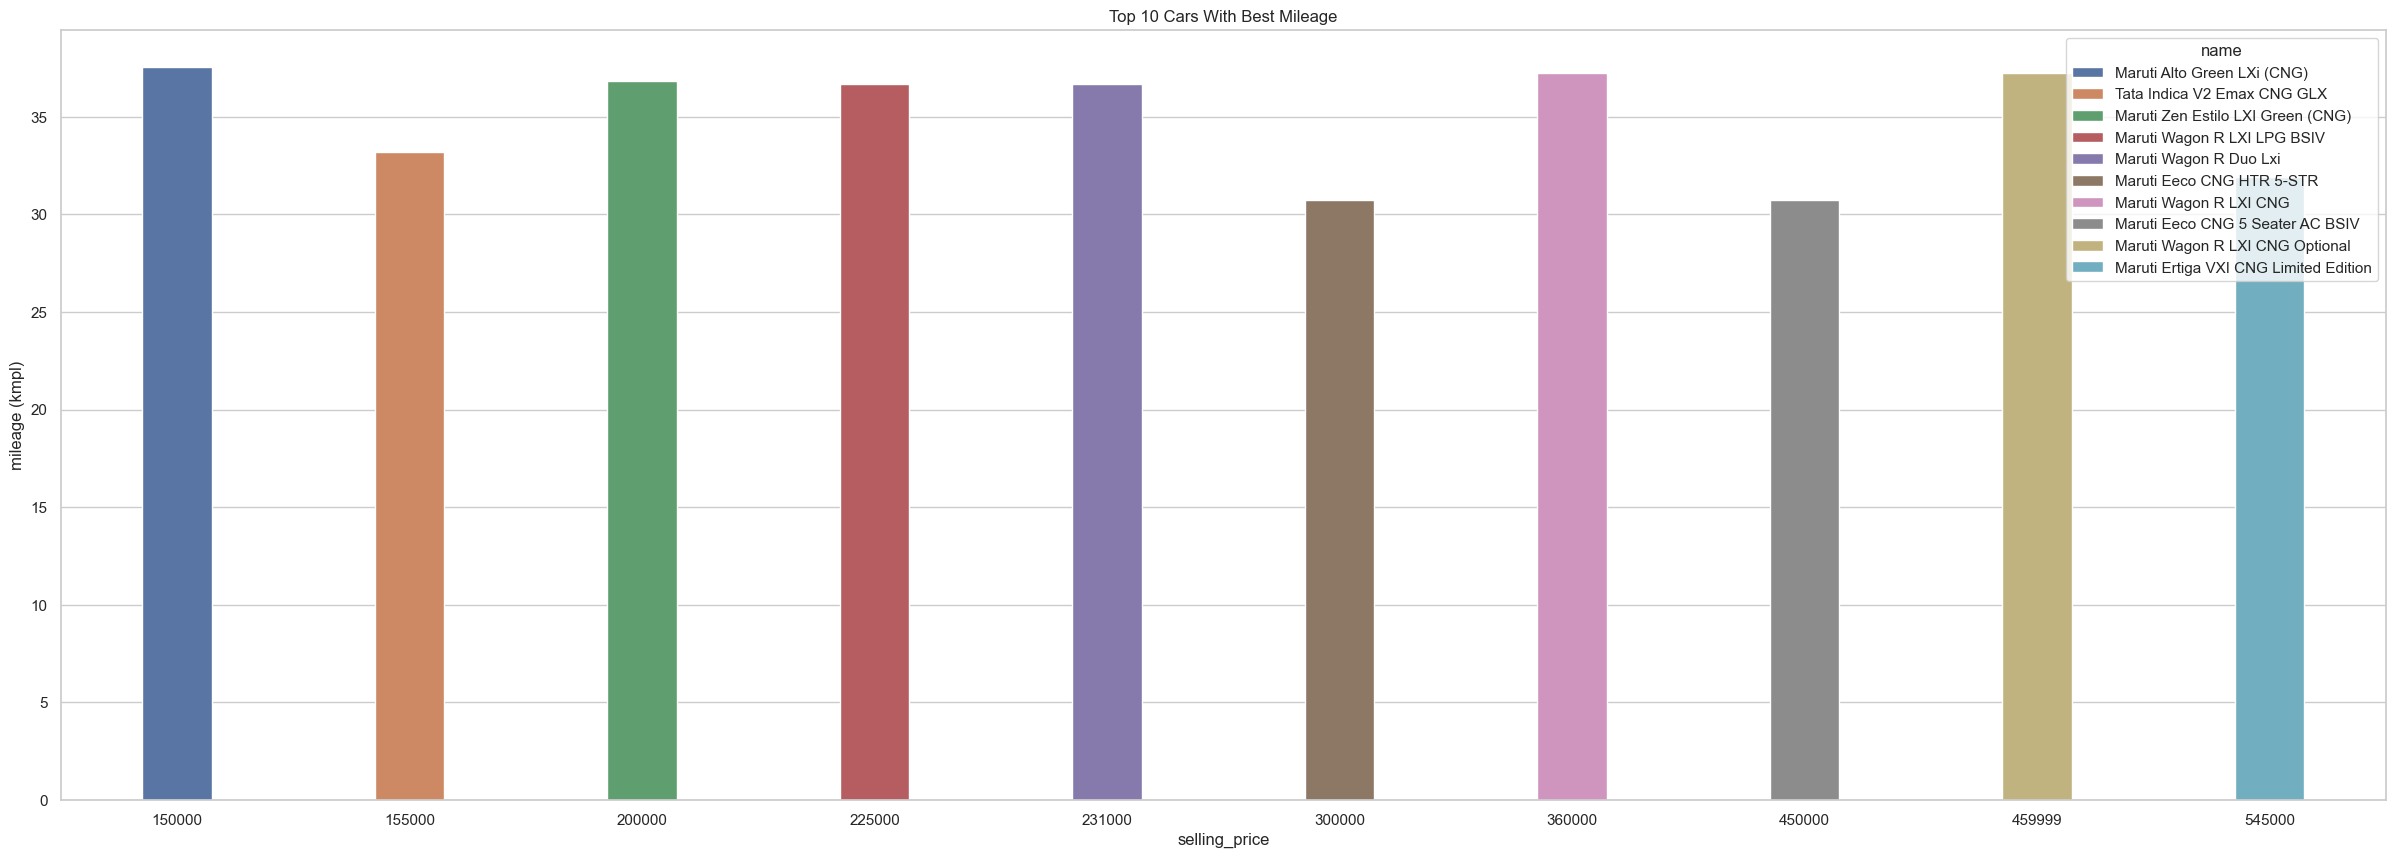

In [1133]:
plt.figure(figsize=(30,10))
plt.title('Top 10 Cars With Best Mileage')
sns.barplot(x=Top10_Cars['selling_price'],y=Top10_Cars['mileage (kmpl)'],hue=Top10_Cars['name'],width=0.3)
plt.show()

# T-Test

H0 There Is No Significiant Difference Between The Mean of Automatic and Manual Transmission
H1 There Is a Significiant Difference Between The Mean of Automatic and Manual Transmission

In [1141]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage (kmpl),engine (cc),max_power (bhp),seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1001 CC - 1500 CC,74.00,5
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1001 CC - 1500 CC,103.52,5
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1001 CC - 1500 CC,78.00,5
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1001 CC - 1500 CC,90.00,5
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1001 CC - 1500 CC,88.20,5


In [1151]:
# Separate the selling prices based on transmission type
manual_prices = df[df['transmission'] == 'Manual']['selling_price']
automatic_prices = df[df['transmission'] == 'Automatic']['selling_price']

# Perform the T-test
t_stat, p_value = stats.ttest_ind(manual_prices, automatic_prices)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# Interpret the result
if p_value < 0.05:
    print("There is a significant difference in selling prices between manual and automatic transmissions.")
else:
    print("There is no significant difference in selling prices between manual and automatic transmissions.")


T-statistic: -19.42318438593985
P-value: 7.942801466865801e-82
There is a significant difference in selling prices between manual and automatic transmissions.


C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16912\2036312490.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='transmission', y='selling_price', data=df, palette=['#6247aa', '#d2b7e5'])


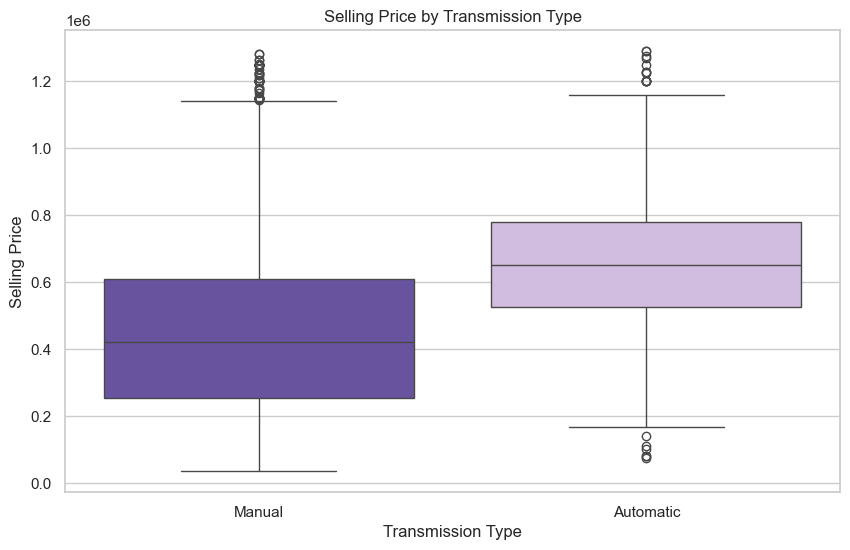

In [1145]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='transmission', y='selling_price', data=df, palette=['#6247aa', '#d2b7e5'])
plt.title('Selling Price by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('Selling Price')
plt.show()


In [1152]:
# Separate the selling prices based on fuel type (e.g., petrol and diesel)
petrol_prices = df[df['fuel'] == 'Petrol']['selling_price']
diesel_prices = df[df['fuel'] == 'Diesel']['selling_price']

# Perform the T-test
t_stat, p_value = stats.ttest_ind(petrol_prices, diesel_prices)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# Interpret the result
if p_value < 0.05:
    print("There is a significant difference in selling prices between petrol and diesel cars.")
else:
    print("There is no significant difference in selling prices between petrol and diesel cars.")


T-statistic: -25.10902267965387
P-value: 4.716553551079361e-133
There is a significant difference in selling prices between petrol and diesel cars.


C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16912\2593320372.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fuel', y='selling_price', data=df, palette=['#6247aa', '#d2b7e5'])
C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_16912\2593320372.py:2: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(x='fuel', y='selling_price', data=df, palette=['#6247aa', '#d2b7e5'])


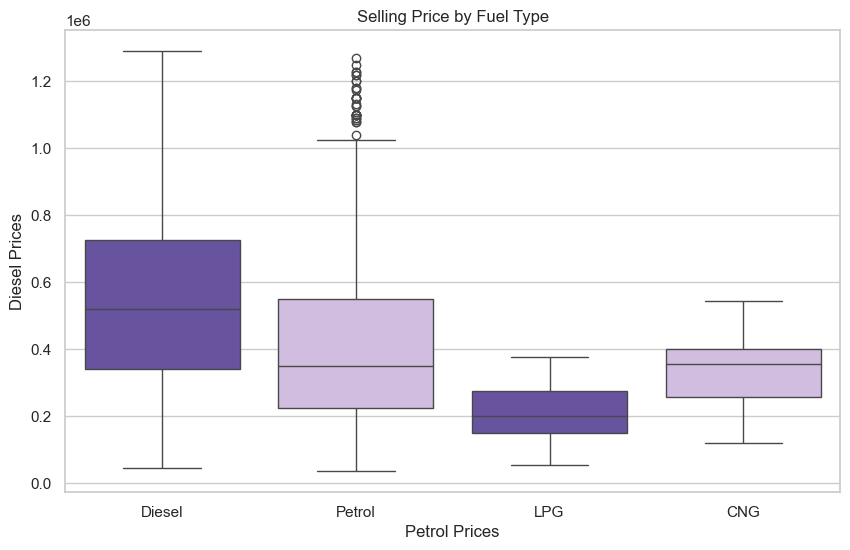

In [1158]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='fuel', y='selling_price', data=df, palette=['#6247aa', '#d2b7e5'])
plt.title('Selling Price by Fuel Type')
plt.xlabel('Petrol Prices')
plt.ylabel('Diesel Prices')
plt.show()
